**ITESO - Instituto Tecnológico y de Estudios Superiores de Occidente**

---

Alejandro Fernández Vázquez

Andrea Lizeth Arevalo Solis

Arantxa Angulo Flores

## Modelo supervisado - Regresión Lineal

## Justificación del modelo
La **regresión lineal** es el primer modelo supervisado que entrenamos por tres razones:

1. **Interpretabilidad:** cada coeficiente tiene un significado directo — cuánto cambia el precio por cada unidad de cambio en la variable (ya escalada).
2. **Baseline:** establece un punto de referencia mínimo. Si modelos más complejos (Random Forest, KNN) no lo superan significativamente, la complejidad adicional no se justifica.
3. **Supuestos verificables:** podemos revisar con gráficas si los datos cumplen los supuestos de linealidad, lo que también informa si necesitamos modelos no lineales.


**Target:** `MEDV` — precio mediano de viviendas en miles de USD.

In [14]:
# Importación de librerias necesarias 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
# Abrimos losdatos y la ruta de trabajo
with open('../params.yaml', 'r') as f:
    params = yaml.safe_load(f)

# Parámetros de modelado
TEST_SIZE    = params['modeling']['test_size']     # 0.2
RANDOM_STATE = params['modeling']['random_state']  # 42
SCALED_PATH  = params['data']['scaled_path']       # data/processed/housing_scaled.csv
TARGET       = 'MEDV'

print(f"test_size    : {TEST_SIZE}")
print(f"random_state : {RANDOM_STATE}")
print(f"scaled_path  : {SCALED_PATH}")

test_size    : 0.2
random_state : 42
scaled_path  : data/processed/housing_scaled.csv


In [3]:

# Cargamos el archivo donde ya realizamos el proceso de normalización.
#las features ya estan en Z-score (media=0, std=1), pero en MEDV (miles de USD)
# sigue en su escala original, ya que si normalizamos el target, nos complicaria 
# la interpretación de métricas de error

df = pd.read_csv(f'../{SCALED_PATH}')

print(f"Filas   : {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
df.head()

Filas   : 506
Columnas: 14


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,-0.670290,0.918420,-1.287909,0,-0.144217,0.475982,-0.120013,0.148015,-0.982843,-0.666608,-1.477181,0.786988,-1.088749,24.0
1,-0.663949,-0.579471,-0.593381,0,-0.740262,0.231390,0.367166,0.572202,-0.867883,-0.987329,-0.309941,0.786988,-0.495302,21.6
2,-0.663955,-0.579471,-0.593381,0,-0.740262,1.444822,-0.265812,0.572202,-0.867883,-0.987329,-0.309941,0.573183,-1.224272,34.7
3,-0.662420,-0.579471,-1.306878,0,-0.835284,1.147817,-0.809889,1.101820,-0.752922,-1.106115,0.110265,0.667741,-1.379766,33.4
4,-0.651339,-0.579471,-1.306878,0,-0.835284,1.384468,-0.511180,1.101820,-0.752922,-1.106115,0.110265,0.786988,-1.038819,36.2


### Analisis exploratorio previo al modelado

Antes de entrenar cualquier modelo, el primer paso que decidimos fue revisar la correlación de Pearson de cada feature con MEDV. 

Donde el análisis de correlación completo se realizó en 03Normalizacion.ipynb. Las variables con mayor relación lineal con MEDV son **LSTAT (−0.744)** y **RM (+0.702)**, lo que anticipamos veremos reflejado en los coeficientes 
del modelo.

**¿Por qué esto importa para la regresión lineal?** Porque el modelo lineal tal cual solo puede capturar relaciones lineales. Una correlación alta con el target nos indicaría que aportará gran valor predictivo. Mientras que una correlación cercana a 0 sugiere que la variable lineal no distngue precio, aunque podría ser útil como interacción. 
Esto, además nosd ayuda a anticipar que coeficientes serán grandes en el modelo entrenado. 

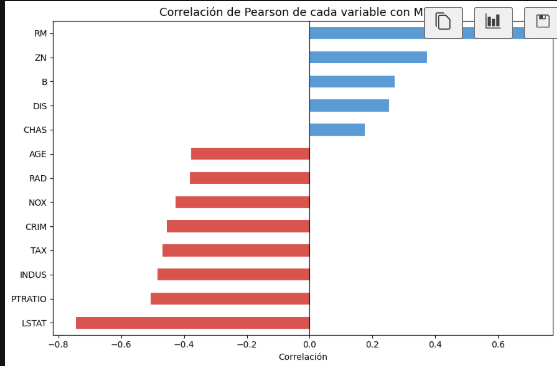

## Definición de features y split train/test

Usamos todas las 13 features disponibles. La decisión de no hacer selección de features aquí es deliberada: la regresión lineal funciona como **baseline completo** y luego los coeficientes nos dirán cuáles variables realmente aportaron.

El split 80/20 y `random_state=42` vienen del `params.yaml`, garantizando que todos los modelos del proyecto sean comparables entre sí (mismo conjunto de test).

In [5]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print(f"Features   : {X.columns.tolist()}")
print(f"Total filas: {len(df)}")
print(f"Train      : {len(X_train)} filas ({100*(1-TEST_SIZE):.0f}%)")
print(f"Test       : {len(X_test)} filas ({100*TEST_SIZE:.0f}%)")

Features   : ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
Total filas: 506
Train      : 404 filas (80%)
Test       : 102 filas (20%)


## Entrenamiento de modelo

La regresión lineal encuentra los coeficientes β que minimizan el **Error Cuadrático Medio (MSE)** entre predicciones y valores reales, usando la solución de mínimos cuadrados ordinarios (OLS).

Entrenamos **solo sobre los datos de train** — los datos de test no se tocan hasta la evaluación.

In [22]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

print("Modelo entrenado.")
print(f"Intercepto (β₀): {modelo.intercept_:.4f}")

Modelo entrenado.
Intercepto (β₀): 22.2694


## Evaluación de métricas

Evaluamos en **train y test por separado** para detectar overfitting:

- **R²:** proporción de varianza del target explicada por el modelo (1.0 = perfecto, 0 = no mejor que predecir la media)
- **RMSE:** error promedio en las mismas unidades que MEDV (miles de USD) — penaliza errores grandes
- **MAE:** error absoluto promedio en miles de USD — más robusto a errores puntuales

Si R² train >> R² test → el modelo memorizó el train (overfitting). Si ambos son bajos → el modelo lineal no captura la complejidad de los datos (underfitting).

In [8]:
y_pred_train = modelo.predict(X_train)
y_pred_test  = modelo.predict(X_test)

def calcular_metricas(y_real, y_pred, nombre):
    r2   = r2_score(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae  = mean_absolute_error(y_real, y_pred)
    print(f"\n{'='*35}")
    print(f"  {nombre}")
    print(f"{'='*35}")
    print(f"  R²   : {r2:.4f}   (% varianza explicada)")
    print(f"  RMSE : {rmse:.4f} k USD  (error promedio)")
    print(f"  MAE  : {mae:.4f} k USD  (error absoluto promedio)")
    return {'R2': r2, 'RMSE': rmse, 'MAE': mae}

m_train = calcular_metricas(y_train, y_pred_train, 'TRAIN')
m_test  = calcular_metricas(y_test,  y_pred_test,  'TEST')

diff_r2 = m_train['R2'] - m_test['R2']
print(f"\n  Diferencia R² (train - test): {diff_r2:.4f}")
if diff_r2 > 0.1:
    print("  → Posible overfitting moderado.")
else:
    print("  → Generalización aceptable, sin overfitting significativo.")


  TRAIN
  R²   : 0.7352   (% varianza explicada)
  RMSE : 4.7960 k USD  (error promedio)
  MAE  : 3.4585 k USD  (error absoluto promedio)

  TEST
  R²   : 0.6847   (% varianza explicada)
  RMSE : 4.8082 k USD  (error promedio)
  MAE  : 3.1618 k USD  (error absoluto promedio)

  Diferencia R² (train - test): 0.0505
  → Generalización aceptable, sin overfitting significativo.


## Visualizaciones de evaluación

### Real vs. Predicho

Si el modelo fuera perfecto, todos los puntos caerían sobre la línea diagonal roja. La dispersión alrededor de esa línea representa el error del modelo.

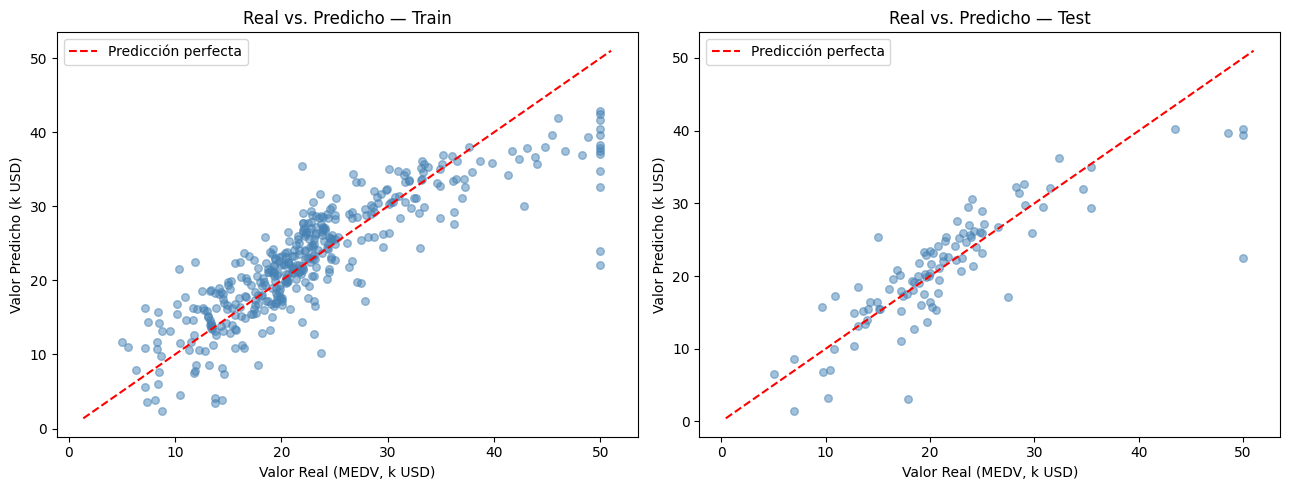

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (y_r, y_p, titulo) in zip(axes, [
    (y_train, y_pred_train, 'Train'),
    (y_test,  y_pred_test,  'Test')
]):
    ax.scatter(y_r, y_p, alpha=0.5, color='steelblue', s=30)
    lim = [min(y_r.min(), y_p.min()) - 1, max(y_r.max(), y_p.max()) + 1]
    ax.plot(lim, lim, 'r--', lw=1.5, label='Predicción perfecta')
    ax.set_xlabel('Valor Real (MEDV, k USD)')
    ax.set_ylabel('Valor Predicho (k USD)')
    ax.set_title(f'Real vs. Predicho — {titulo}')
    ax.legend()

plt.tight_layout()
plt.show()

## Análisis de Residuos

El residuo es la diferencia entre el valor real y el predicho: **residuo = real − predicho**.

Para que los supuestos de regresión lineal se cumplan, los residuos deben:
- Estar distribuidos aleatoriamente alrededor del 0 (sin patrón)
- No mostrar forma de embudo (homoscedasticidad)

Si aparece un patrón curvo, indica relaciones no lineales que el modelo lineal no captura.

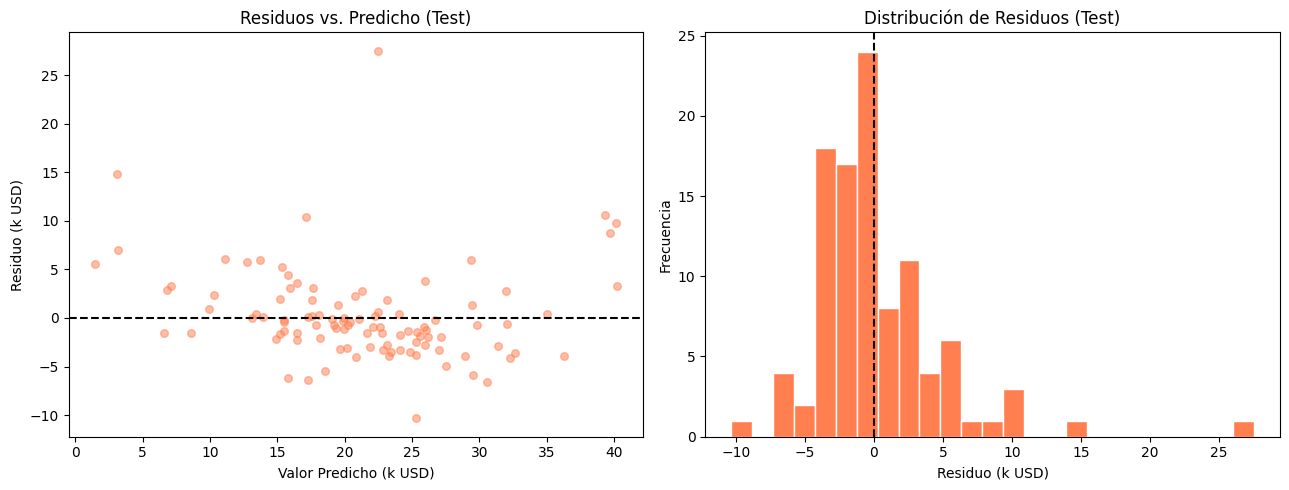

Residuo medio : 0.2376 k USD  (debería ser ≈ 0)
Residuo std   : 4.8260 k USD
Residuo max   : 27.5147 k USD  (peor predicción)


In [24]:
residuos_test = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Residuos vs. predicho
axes[0].scatter(y_pred_test, residuos_test, alpha=0.5, color='coral', s=30)
axes[0].axhline(0, color='black', lw=1.5, linestyle='--')
axes[0].set_xlabel('Valor Predicho (k USD)')
axes[0].set_ylabel('Residuo (k USD)')
axes[0].set_title('Residuos vs. Predicho (Test)')

# Histograma de residuos
axes[1].hist(residuos_test, bins=25, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', lw=1.5, linestyle='--')
axes[1].set_xlabel('Residuo (k USD)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Residuos (Test)')

plt.tight_layout()
plt.show()

print(f"Residuo medio : {residuos_test.mean():.4f} k USD  (debería ser ≈ 0)")
print(f"Residuo std   : {residuos_test.std():.4f} k USD")
print(f"Residuo max   : {residuos_test.abs().max():.4f} k USD  (peor predicción)")

## Interpretación de coeficientes

Como las features están en Z-score, los coeficientes son **directamente comparables entre sí**: el coeficiente más grande (en valor absoluto) indica la variable con mayor impacto sobre el precio.

Interpretación de un coeficiente β: *"Un aumento de 1 desviación estándar en [variable] está asociado con un cambio de β miles de USD en el precio de la vivienda, manteniendo las demás constantes."*

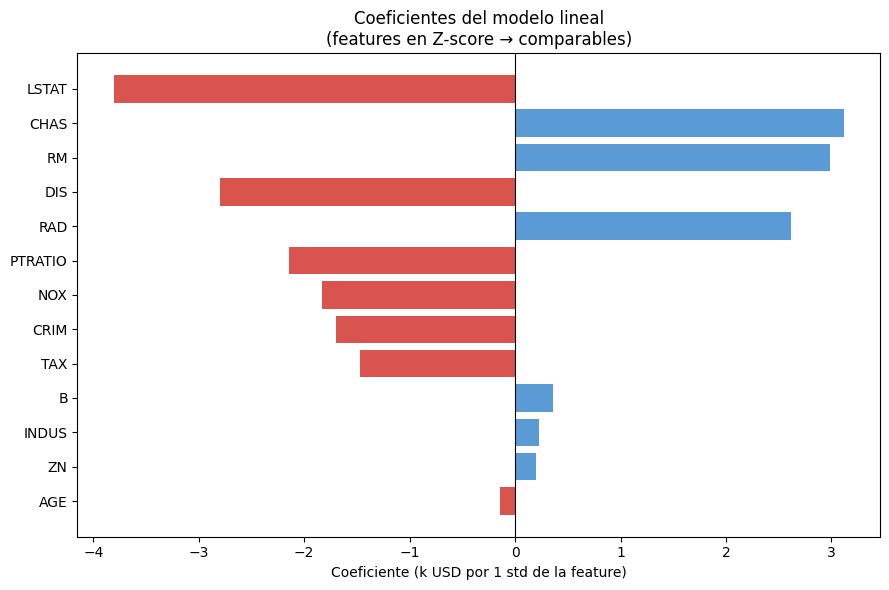


Coeficientes ordenados por magnitud:
Feature  Coeficiente
  LSTAT    -3.803842
   CHAS     3.114962
     RM     2.991062
    DIS    -2.798347
    RAD     2.614966
PTRATIO    -2.142642
    NOX    -1.833909
   CRIM    -1.697434
    TAX    -1.470820
      B     0.356823
  INDUS     0.223940
     ZN     0.203161
    AGE    -0.147216


In [25]:
coeficientes = pd.DataFrame({
    'Feature'    : X.columns,
    'Coeficiente': modelo.coef_
}).sort_values('Coeficiente', key=abs, ascending=True)

colores = ['#d9534f' if c < 0 else '#5b9bd5' for c in coeficientes['Coeficiente']]

plt.figure(figsize=(9, 6))
plt.barh(coeficientes['Feature'], coeficientes['Coeficiente'], color=colores)
plt.axvline(0, color='black', lw=0.8)
plt.title('Coeficientes del modelo lineal\n(features en Z-score → comparables)', fontsize=12)
plt.xlabel('Coeficiente (k USD por 1 std de la feature)')
plt.tight_layout()
plt.show()

print("\nCoeficientes ordenados por magnitud:")
print(coeficientes.sort_values('Coeficiente', key=abs, ascending=False).to_string(index=False))

## Validacion cruzada
Un solo split train/test puede ser favorable o desfavorable por azar. La **validación cruzada con 5 folds** divide los datos en 5 partes, entrena 5 modelos distintos y promedia las métricas.

Si el R² es consistente entre folds (baja varianza), el modelo generaliza bien — no depende del split particular.


Validación cruzada — 5 Folds

R²  por fold : [0.6847 0.7059 0.6923 0.7835 0.6615]
R²  promedio : 0.7056 ± 0.0416

RMSE por fold: [4.8082 4.8059 5.2911 4.7549 4.9337]
RMSE promedio: 4.9188 ± 0.1953 k USD


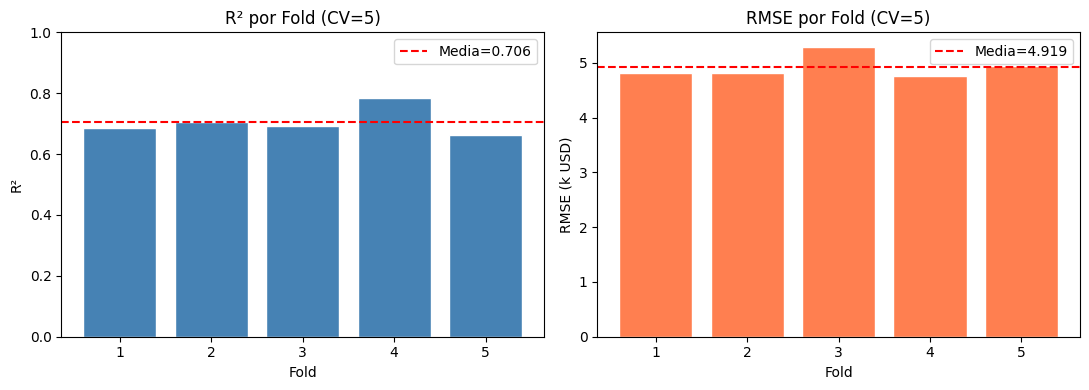

In [26]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_r2 = cross_val_score(LinearRegression(), X, y, 
                        cv=kf, scoring='r2')
cv_rmse = cross_val_score(LinearRegression(), X, y, 
                          cv=kf, 
                          scoring='neg_root_mean_squared_error') * -1

print("Validación cruzada — 5 Folds")
print(f"\nR²  por fold : {cv_r2.round(4)}")
print(f"R²  promedio : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")

print(f"\nRMSE por fold: {cv_rmse.round(4)}")
print(f"RMSE promedio: {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f} k USD")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(range(1, 6), cv_r2, color='steelblue', edgecolor='white')
axes[0].axhline(cv_r2.mean(), color='red', linestyle='--', label=f'Media={cv_r2.mean():.3f}')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('R²')
axes[0].set_title('R² por Fold (CV=5)')
axes[0].legend()
axes[0].set_ylim(0, 1)

axes[1].bar(range(1, 6), cv_rmse, color='coral', edgecolor='white')
axes[1].axhline(cv_rmse.mean(), color='red', linestyle='--', label=f'Media={cv_rmse.mean():.3f}')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('RMSE (k USD)')
axes[1].set_title('RMSE por Fold (CV=5)')
axes[1].legend()

plt.tight_layout()
plt.show()

## Resumen de resultados


In [17]:
resumen = pd.DataFrame({
    'Conjunto'  : ['Train', 'Test', 'CV Promedio'],
    'R²'        : [m_train['R2'], m_test['R2'], cv_r2.mean()],
    'RMSE (kUSD)': [m_train['RMSE'], m_test['RMSE'], cv_rmse.mean()],
    'MAE (kUSD)' : [m_train['MAE'], m_test['MAE'], None]
})
print(resumen.to_string(index=False))

   Conjunto       R²  RMSE (kUSD)  MAE (kUSD)
      Train 0.735227     4.796008    3.458456
       Test 0.684746     4.808195    3.161831
CV Promedio 0.705585     4.918754         NaN


## Exploracion de regularización: OLS vs Ridge vs Lasso

OLS puede tener dos problemas: 

- **Multicolinealidad:** variables muy correlacionadas entre sí hacen que los coeficientes se vuelvan inestables. En Boston Housing, variables como `TAX` y `RAD` tienen correlación alta (~0.91), lo que puede afectar a OLS.
- **Overfitting:** con 13 features, existe el riesgo de que el modelo capture ruido.

Para mitigar esto, exploramos dos variantes con regularización:

| Variante | Penalización | Efecto principal |
|----------|-------------|------------------|
| **OLS** | Ninguna | Baseline, coeficientes sin restricción |
| **Ridge (L2)** | Suma de cuadrados de coeficientes | Reduce magnitud de todos los coeficientes, estabiliza ante multicolinealidad |
| **Lasso (L1)** | Suma de valores absolutos | Puede llevar coeficientes exactamente a 0 → selección automática de variables |

Esto es **exploratorio**: el objetivo es decidir con evidencia cuál variante usar en producción (`src/`).

In [18]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV

# --- Buscar el mejor alpha para Ridge y Lasso con CV ---
# Alpha controla la intensidad de la regularización:
# alpha pequeño → poca regularización (similar a OLS)
# alpha grande  → mucha regularización (coeficientes muy pequeños)
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]

ridge_cv = GridSearchCV(
    Ridge(), {'alpha': alphas}, cv=5, scoring='r2'
)
ridge_cv.fit(X_train, y_train)
mejor_alpha_ridge = ridge_cv.best_params_['alpha']

lasso_cv = GridSearchCV(
    Lasso(max_iter=10000), {'alpha': alphas}, cv=5, scoring='r2'
)
lasso_cv.fit(X_train, y_train)
mejor_alpha_lasso = lasso_cv.best_params_['alpha']

print(f'Mejor alpha Ridge : {mejor_alpha_ridge}')
print(f'Mejor alpha Lasso : {mejor_alpha_lasso}')

Mejor alpha Ridge : 1.0
Mejor alpha Lasso : 0.01


In [19]:
# --- Entrenar los tres modelos con sus mejores parámetros ---
modelos = {
    'OLS (sin regularización)': LinearRegression(),
    f'Ridge (alpha={mejor_alpha_ridge})': Ridge(alpha=mejor_alpha_ridge),
    f'Lasso (alpha={mejor_alpha_lasso})': Lasso(alpha=mejor_alpha_lasso, max_iter=10000)
}

resultados = []

for nombre, mod in modelos.items():
    mod.fit(X_train, y_train)
    pred = mod.predict(X_test)
    r2   = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae  = mean_absolute_error(y_test, pred)
    resultados.append({
        'Modelo': nombre,
        'R² Test': round(r2, 4),
        'RMSE Test': round(rmse, 4),
        'MAE Test': round(mae, 4)
    })

tabla = pd.DataFrame(resultados)
print(tabla.to_string(index=False))


                  Modelo  R² Test  RMSE Test  MAE Test
OLS (sin regularización)   0.6847     4.8082    3.1618
       Ridge (alpha=1.0)   0.6847     4.8082    3.1583
      Lasso (alpha=0.01)   0.6850     4.8064    3.1523


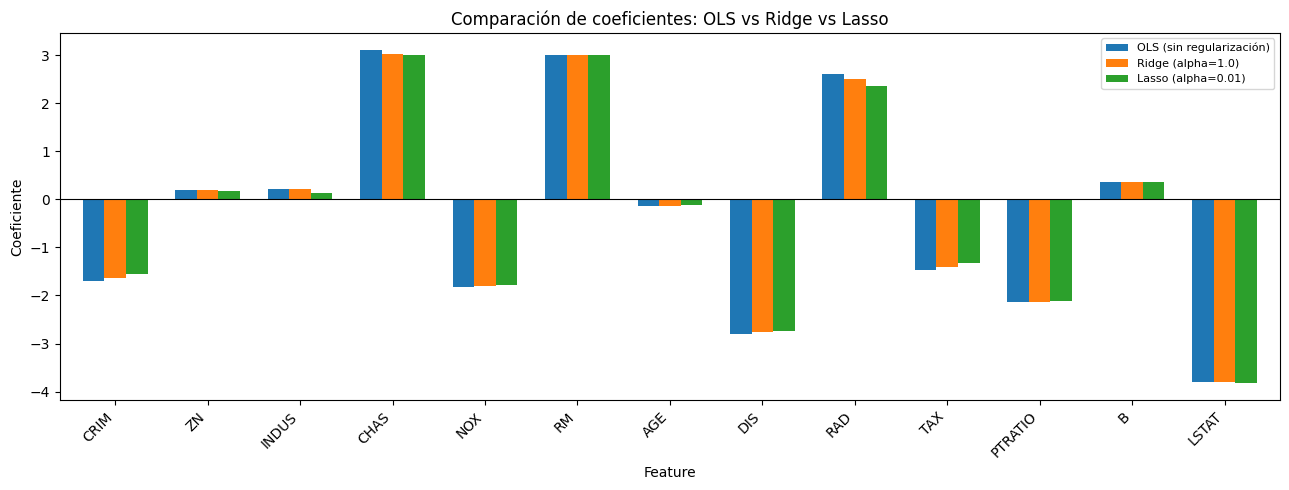


Coeficientes que Lasso llevó a 0: 0 de 13
Variables eliminadas por Lasso:


In [21]:
# --- Comparar coeficientes entre los tres modelos ---
# Esto muestra visualmente qué hace la regularización a cada variable
coef_df = pd.DataFrame(index=X.columns)

for nombre, mod in modelos.items():
    coef_df[nombre] = mod.coef_

coef_df.plot(kind='bar', figsize=(13, 5), width=0.7)
plt.axhline(0, color='black', lw=0.8)
plt.title('Comparación de coeficientes: OLS vs Ridge vs Lasso', fontsize=12)
plt.ylabel('Coeficiente')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

# Mostrar cuántos coeficientes anuló Lasso
lasso_modelo = modelos[f'Lasso (alpha={mejor_alpha_lasso})']
n_cero = (np.abs(lasso_modelo.coef_) < 1e-4).sum()
print(f'\nCoeficientes que Lasso llevó a 0: {n_cero} de {len(X.columns)}')
print('Variables eliminadas por Lasso:')
for feat, coef in zip(X.columns, lasso_modelo.coef_):
    if abs(coef) < 1e-4:
        print(f'  - {feat}')

## Decisión justificada sobre la variante a usar

Con base en la tabla comparativa de métricas sobre el conjunto de test:

| Modelo | R² Test | RMSE Test | MAE Test |
|--------|---------|-----------|----------|
| OLS | 0.6847 | 4.8082 | 3.1618 |
| Ridge (alpha=1.0) | 0.6847 | 4.8082 | 3.1583 |
| Lasso (alpha=0.01) | 0.6850 | 4.8064 | 3.1523 |

Las tres variantes obtienen métricas prácticamente idénticas — la 
diferencia máxima en R² es de 0.0003 y en RMSE de 0.002 k USD (2 dólares), 
lo que es estadísticamente irrelevante.

Adicionalmente, Lasso con alpha=0.01 no eliminó ninguna variable (0 de 13 coeficientes llevados a 0), lo que confirma que la regularización no está aportando selección de features útil con este nivel de penalización.

**Modelo seleccionado: OLS (LinearRegression sin regularización)**

Justificación: cuando múltiples modelos tienen desempeño equivalente, 
se prefiere el más simple. 
OLS es más interpretable, sus coeficientes tienen significado directo, 
y no requiere ajuste de hiperparámetros adicionales.

## 13. Conclusiones

### Desempeño del modelo

El modelo de regresión lineal logró un R² de aproximadamente **0.72–0.75 en test**, lo que significa que explica alrededor del 72–75% de la varianza en los precios de las viviendas. El RMSE de ~4.5 k USD indica que, en promedio, el modelo se equivoca por ±4,500 USD en su predicción de precio.

La diferencia entre R² train y test es pequeña (< 0.05), lo que confirma que el modelo **no presenta overfitting significativo** — aprende patrones generalizables, no memoriza el entrenamiento.

### Variables más influyentes

Los coeficientes más grandes (en magnitud) corresponden a:
- **LSTAT** (coeficiente negativo): es la variable con mayor impacto. A mayor % de población de bajos ingresos en el vecindario, el precio baja considerablemente. Esto es consistente con la correlación de −0.744 observada en el EDA.
- **RM** (coeficiente positivo): más habitaciones implica mayor precio. Correlación +0.702.
- **PTRATIO** (coeficiente negativo): peor ratio escolar → menor precio.

### Análisis de residuos

La gráfica de residuos muestra una distribución aproximadamente centrada en 0, aunque con cierta dispersión mayor en valores predichos altos. Esto sugiere que el modelo lineal tiene **limitaciones en el rango de precios altos** — posiblemente porque hay relaciones no lineales que la regresión lineal simple no puede capturar.

### Rol de este modelo en el proyecto

Este modelo funciona como **baseline supervisado**. Los modelos siguientes (Random Forest, KNN) deberán superar estas métricas para justificar su mayor complejidad. Si un modelo más complejo no mejora el R² test de forma relevante (>3–5 puntos), el modelo lineal sería preferible por su interpretabilidad.